In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import colorsys
import pandas as pd
from pathlib import Path
from hypo_sleep import Session
import spikeinterface.full as si
import spikeinterface.preprocessing as spp
from scipy import signal, stats
import xarray as xr
import statsmodels.api as sm
from functools import partial
from ghostipy.dsp import signal_envelope

In [2]:
def xr_baseline_correction(data, baseline_segment):
    if not isinstance(baseline_segment, slice):
        baseline_segment = slice(baseline_segment[0], baseline_segment[1])
    baseline_data = data.sel(time=baseline_segment).copy()
    corrected_data = (
        (data - baseline_data.mean(dim="time")) / baseline_data.mean(dim="time")
    ) * 100
    return corrected_data

In [3]:
SMALL_SIZE = 20
MEDIUM_SIZE = 24
BIGGER_SIZE = 28
BIGGEST_SIZE = 38

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=BIGGER_SIZE)  # fontsize of the axes titlea
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=MEDIUM_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=MEDIUM_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)
plt.rc("figure", labelsize=BIGGEST_SIZE)

In [4]:
data_path = Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/")
full_dict = {
    "HYDO03": {
        "dates": ["2025-02-18_09-19-26", "2025-02-20_08-58-57"],
        "configs": ["85bd", "edfe"],  # ["f1b1", "5fdd"],
    },
    "HYDO04": {
        "dates": ["2025-02-24_09-00-29", "2025-02-26_09-05-08"],
        "configs": ["8e29", "d678"],
    },
}
depth_ordered_chs = np.array(
    [
        "24",
        "23",
        "25",
        "22",
        "8",
        "7",
        "9",
        "6",
        "15",
        "0",
        "14",
        "1",
        "26",
        "21",
        "27",
        "20",
        "10",
        "5",
        "28",
        "19",
        "11",
        "4",
        "29",
        "18",
        "12",
        "3",
        "30",
        "17",
        "13",
        "2",
        "31",
        "16",
    ]
)

In [5]:
config_path = Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/")
# data_path = Path("/mnt/data/raw/", animal, date)
data_path = Path("/gpfs01/born/animal/Hypothalamic_Sleep/data/raw")

In [6]:
session_dict = {}
# animal = "HYDO03"
# animal_dict = full_dict[animal]
# animal = "HYDO03"
# date = "2025-02-18_09-19-26"
# config_id = "85bd"
sub_channels = np.array(["28", "10", "25", "0", "20", "23"])
# animal = "HYDO03"
# date = "2025-02-20_08-58-57"
# config_id = "2198"
# sub_channels = np.array(["12", "28", "9", "22", "16", "18"])

# animal = "HYDO04"
# date = "2025-02-24_09-00-29"
# config_id = "8e29"
# sub_channels = np.array(["26", "10", "31", "8", "24", "7", "16", "19", "20"])
for animal in full_dict.keys():
    animal_dict = full_dict[animal]
    for date, config_id in zip(animal_dict["dates"], animal_dict["configs"]):
        session_dict[date] = Session(
            config_path, animal, date, config_id, **{"base_path": "remote"}
        )

In [7]:
def artifact_detection(recording, **params):
    artf_thresh = params.get("artifact_detect_std_thresh", np.inf)

    if params.get("artifact_detect_method") == "zscore":
        art_rec = spp.zscore(recording)
    artifacts = np.zeros(
        (recording.get_num_channels(), recording.get_num_samples()), dtype=bool
    )
    artifact_ch_list = []
    for i, ch in enumerate(art_rec.get_channel_ids()):
        artifact_ch_list.append(ch)
        artifacts[
            i,
            np.where(
                np.abs(
                    art_rec.get_traces(channel_ids=[ch], return_scaled=True).flatten()
                )
                > artf_thresh
            )[0],
        ] = True
    ch_artifact_sum = np.sum(artifacts, axis=0)
    ch_count_remove = max(
        int(recording.get_num_channels() * params.get("artifact_detect_ch_frac", 1)), 1
    )
    above_thresh = np.ravel(np.argwhere(ch_artifact_sum >= ch_count_remove))
    return above_thresh

In [10]:
window = 10.001
rec_dict = {
    date: {
        region: {filt_type: [] for filt_type in ["raw", "so"]}
        for region in ["ctx", "hyp"]
    }
    for date in session_dict.keys()
}
params = {
    "artifact_detect_ch_frac": 0.2,
    "artifact_detect_method": "zscore",
    "artifact_detect_std_thresh": 4.0,
    "artifact_removal_ms": 0.5,
}
for animal, animal_dict in full_dict.items():
    for date in animal_dict["dates"]:
        for region in rec_dict[date].keys():
            for filt_type in ["raw", "so"]:
                if filt_type == "raw":
                    ref_id = (
                        "250_132b_ctx_global_fe80"
                        if region == "hyp"
                        else "250_132b_none_1da2"
                    )
                elif filt_type == "so":
                    ref_id = "ctx_global_fe80_so_3c1a"  # if region == "hyp" else "none_1da2")
                rec_dir = list(
                    Path(config_path, animal, date, "rec", region).glob(ref_id)
                )[0]
                recording = si.load(rec_dir)
                artifact_triggers = artifact_detection(recording, **params)
                clean_rec = spp.remove_artifacts(
                    recording=recording,
                    list_triggers=artifact_triggers,
                    mode="zeros",
                    fit_sample_spacing=4.0,
                    ms_before=params["artifact_removal_ms"],
                    ms_after=params["artifact_removal_ms"],
                )
                rec_dict[date][region][filt_type] = clean_rec

In [11]:
# sub_ch_inds = np.array([0, 3, 4, 14, 20, 24])
# sub_ch_inds = np.array([0, 2, 9, 13, 15, 18, 22, 28, 30])
trace_dict = {
    date: {
        state: {
            region: {sig_type: {"trace": [], "time": []} for sig_type in recs.keys()}
            for region, recs in rec_dict[date].items()
        }
        for state in session.state_dict.keys()
    }
    for date, session in session_dict.items()
}
for date, session in session_dict.items():
    for state, state_info in session.state_dict.items():
        for region, recs in rec_dict[date].items():
            for sig_type, rec in recs.items():
                channels = (
                    ["39"] if region == "ctx" else rec.get_channel_ids()
                )  # sub_channels
                for start, stop in state_info["times"].T:
                    if stop - start < 60:
                        continue
                    tmp_rec = rec.time_slice(start_time=start, end_time=stop)
                    trace_dict[date][state][region][sig_type]["time"].append(
                        tmp_rec.get_times()
                    )
                    tmp_trace = tmp_rec.get_traces(
                        channel_ids=channels, return_scaled=True
                    )
                    tmp_trace[np.where(tmp_trace == 0)] = np.nan
                    trace_dict[date][state][region][sig_type]["trace"].append(tmp_trace)

### Hypnogram

In [10]:
scoring = np.array([int(val) for val in session.scoring if val < 5], dtype=int)
hypno_time = np.arange(len(session.scoring)) / 360
hypno_time = hypno_time[np.where(session.scoring < 5)]
scoring[np.where(scoring == 3)] = 5
scoring[np.where(scoring == 4)] = 3
scoring[np.where(scoring == 5)] = 4

In [11]:
sub_ordered_chs = sub_channels[
    np.argsort([np.where(depth_ordered_chs == ch)[0][0] for ch in sub_channels])
]

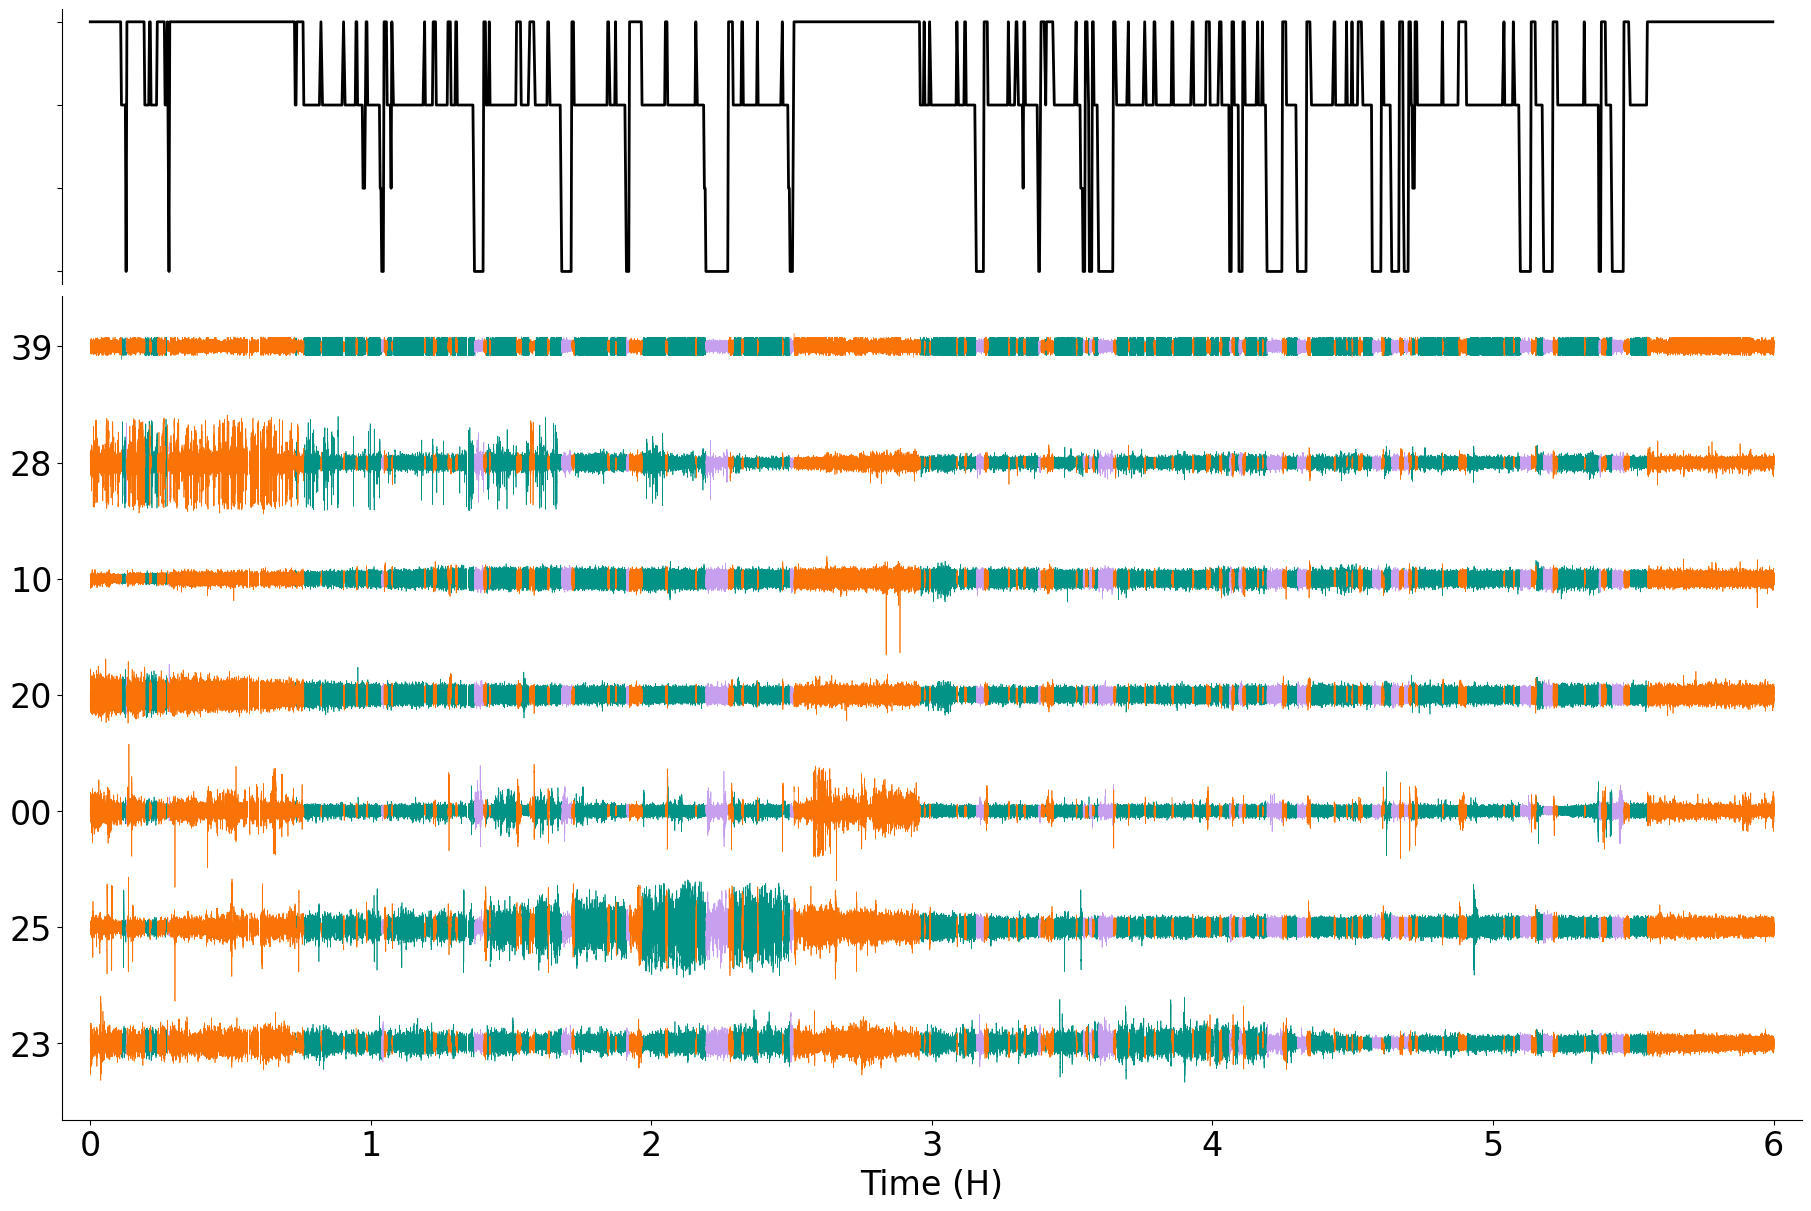

In [24]:
color_dict = {"NREM": "#029386", "REM": "#c79fef", "WAKE": "#f97306"}
fig, axs = plt.subplots(
    nrows=2,
    figsize=(18, 12),
    sharex=True,
    constrained_layout=True,
    height_ratios=[1, 3],
)
ax0 = axs[0]
ax0.plot(hypno_time, scoring, lw=2, c="k")  # color="#029386")
ax0.invert_yaxis()
# labels = ["WAKE", "NREM", "PRE-REM", "REM"]
labels = ["", "", "", ""]
ax0.set_yticks([1, 2, 3, 4], labels=labels)  # , fontsize=20)
ax0.xaxis.set_tick_params(bottom=False, top=False)
ax0.spines[["top", "right", "bottom"]].set_visible(False)

ind = 0
# for region, reg_rec in rec_dict.items():
for region in ["hyp", "ctx"]:
    reg_rec = rec_dict[region]
    channels = ["39"] if region == "ctx" else sub_ordered_chs
    for ch in channels:
        # ax.sharex(ax0)
        for state, state_dict in session.state_dict.items():
            for start, stop in state_dict["times"].T:
                tmp_rec = reg_rec["raw"].time_slice(start_time=start, end_time=stop)
                tmp_trace = tmp_rec.get_traces(channel_ids=[ch], return_scaled=True)
                axs[1].plot(
                    (tmp_rec.get_times() / 3600),
                    tmp_trace + (3000 * ind),
                    lw=0.5,
                    c=color_dict[state],
                    label=state,
                )
        ind += 1
axs[1].spines[["top", "right"]].set_visible(False)
# axs_list[0][0].set_ylabel(f"CTX\nAmplitude $\mu V$", fontsize=20)
# axs[1].set_ylim([-1500, 3000 * (len(sub_channels) + 0.7)])
axs[1].set_yticks(
    np.arange(0, (len(sub_ordered_chs) * 3000) + 1, 3000),
    labels=[f"{int(ch):02d}" for ch in [*sub_ordered_chs, "39"]],
)
axs[-1].set_xlabel("Time (H)")
axs[-1].set_xlim([-0.1, 6.1])
# handles, labels = axs[1].get_legend_handles_labels()
# unique = [
#     (h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]
# ]
# leg = axs[1].legend(*zip(*unique), ncol=3, loc="upper right", fontsize=16)
# for line in leg.get_lines():
#     line.set_linewidth(3)
fig.savefig(
    Path(
        "/gpfs01/born/animal/DanielG/hypo_sleep/figures/plots/",
        "hypnogram_raw_traces_chs_3.png",
    ),
    dpi=500,
    bbox_inches="tight",
    facecolor="white",
    transparent=False,
)

### Plot example short snippet per state/region

In [46]:
def vary_saturation(rgb, factor):
    h, l, s = colorsys.rgb_to_hls(*rgb)
    s = max(0, min(1, s * factor))
    return colorsys.hls_to_rgb(h, l, s)


def vary_lightness(rgb, factor):
    h, l, s = colorsys.rgb_to_hls(*rgb)
    l = max(0, min(1, l * factor))
    return colorsys.hls_to_rgb(h, l, s)


color_palette = {}
for state, hex in color_dict.items():
    base_rgb = mcolors.to_rgb(hex)
    factors = np.linspace(0.5, 1.5, 6)  # darker to lighter
    factors = factors[np.abs(1 - np.linspace(0.5, 1.5, 6)).argsort()]
    colors = [vary_lightness(base_rgb, f) for f in factors]
    color_palette[state] = colors

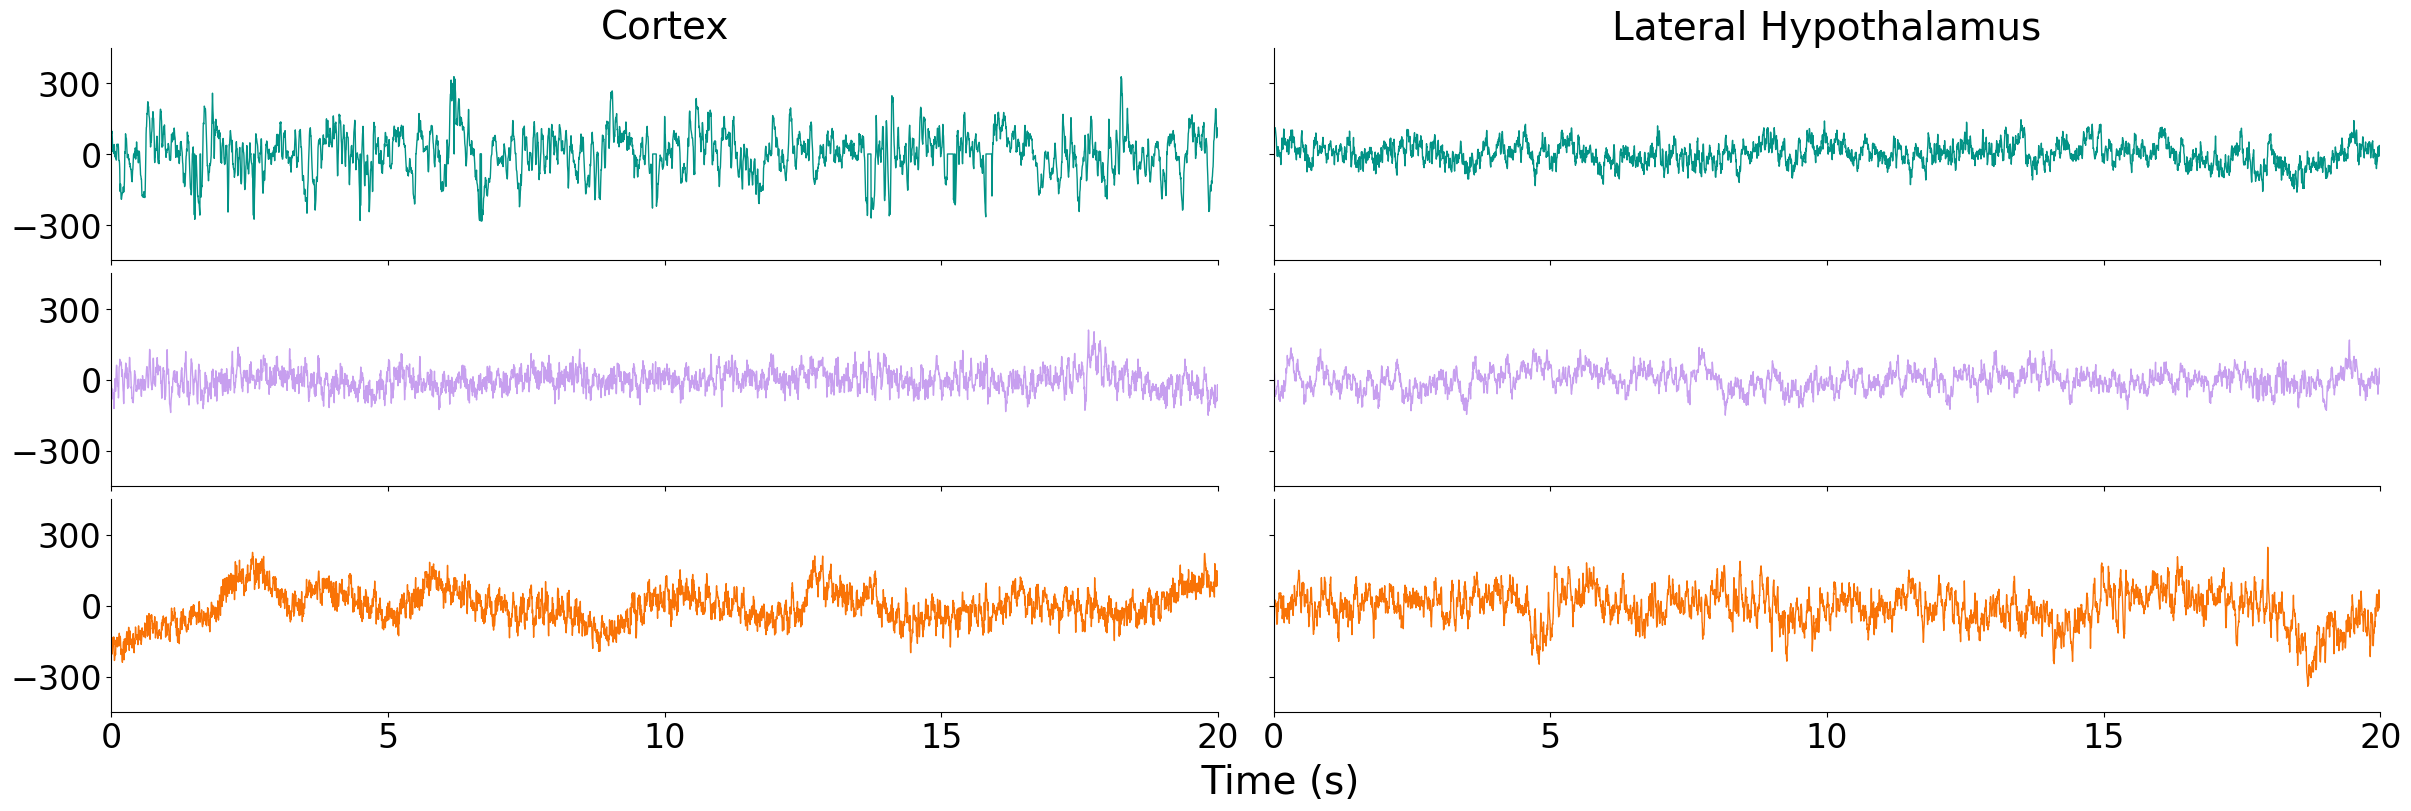

In [67]:
color_dict = {"NREM": "#029386", "REM": "#c79fef", "WAKE": "#f97306"}
fig, axs = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(24, 8),
    sharey=True,
    sharex=True,
    constrained_layout=True,
)
window = 20
tmp_time = np.arange(0, window, 1 / 250)
for ind, (trig, trig_sigs) in enumerate(trace_dict.items()):
    tmp_axs = axs[ind, :]
    for reg_ind, (region, sigs) in enumerate(trig_sigs.items()):
        ind = 0 if region == "ctx" else 3
        tmp_ax = tmp_axs[reg_ind]
        # for sig_type, traces in sigs.items():
        tmp_ax.plot(
            tmp_time,
            # sigs["raw"]["trace"][3][250 * 45 : 250 * (45 + window), ind],
            sigs["raw"]["trace"][3][250 * 15 : 250 * (15 + window), ind],
            label="raw",
            lw=1,
            alpha=1,
            c=color_dict[trig],
        )
        # ax2 = tmp_ax.twinx()
        # ax2.plot(sigs["so"][3][250 * 10 : 250 * 30], label="so-filt", c="r")
        tmp_ax.set_xlim(0, window)
        tmp_ax.spines[["top", "right"]].set_visible(False)
        # tmp_ax.set_title(f"{trig}")
# ax2.legend()
# axs[0, 0].set_ylabel("NREM", rotation=0)
# axs[1, 0].set_ylabel("REM", rotation=0)
# axs[2, 0].set_ylabel("WAKE", rotation=0)
axs[0, 0].set_ylim([-450, 450])
axs[0, 0].set_yticks(ticks=np.arange(-300, 301, 300))
axs[0, 0].set_xticks(ticks=np.arange(0, window + 1, np.ceil((window + 1) / 5)))
# axs[-1, -1].legend(markerscale=10, numpoints=100)
axs[0, 0].set_title("Cortex")
axs[0, 1].set_title("Lateral Hypothalamus")
# fig.supylabel("Amplitude ($\\mu$V)", x=-0.02, fontsize=BIGGER_SIZE)
fig.supxlabel("            Time (s)", fontsize=BIGGER_SIZE)
fig.savefig(
    Path(
        "/gpfs01/born/animal/DanielG/hypo_sleep/figures/plots/",
        "raw_trace_across_brain_states_1.png",
    ),
    dpi=600,
    facecolor="white",
    transparent=False,
    bbox_inches="tight",
)
# # fig.suptitle("Raw Trace across Brain States and Regions", y=1.04)

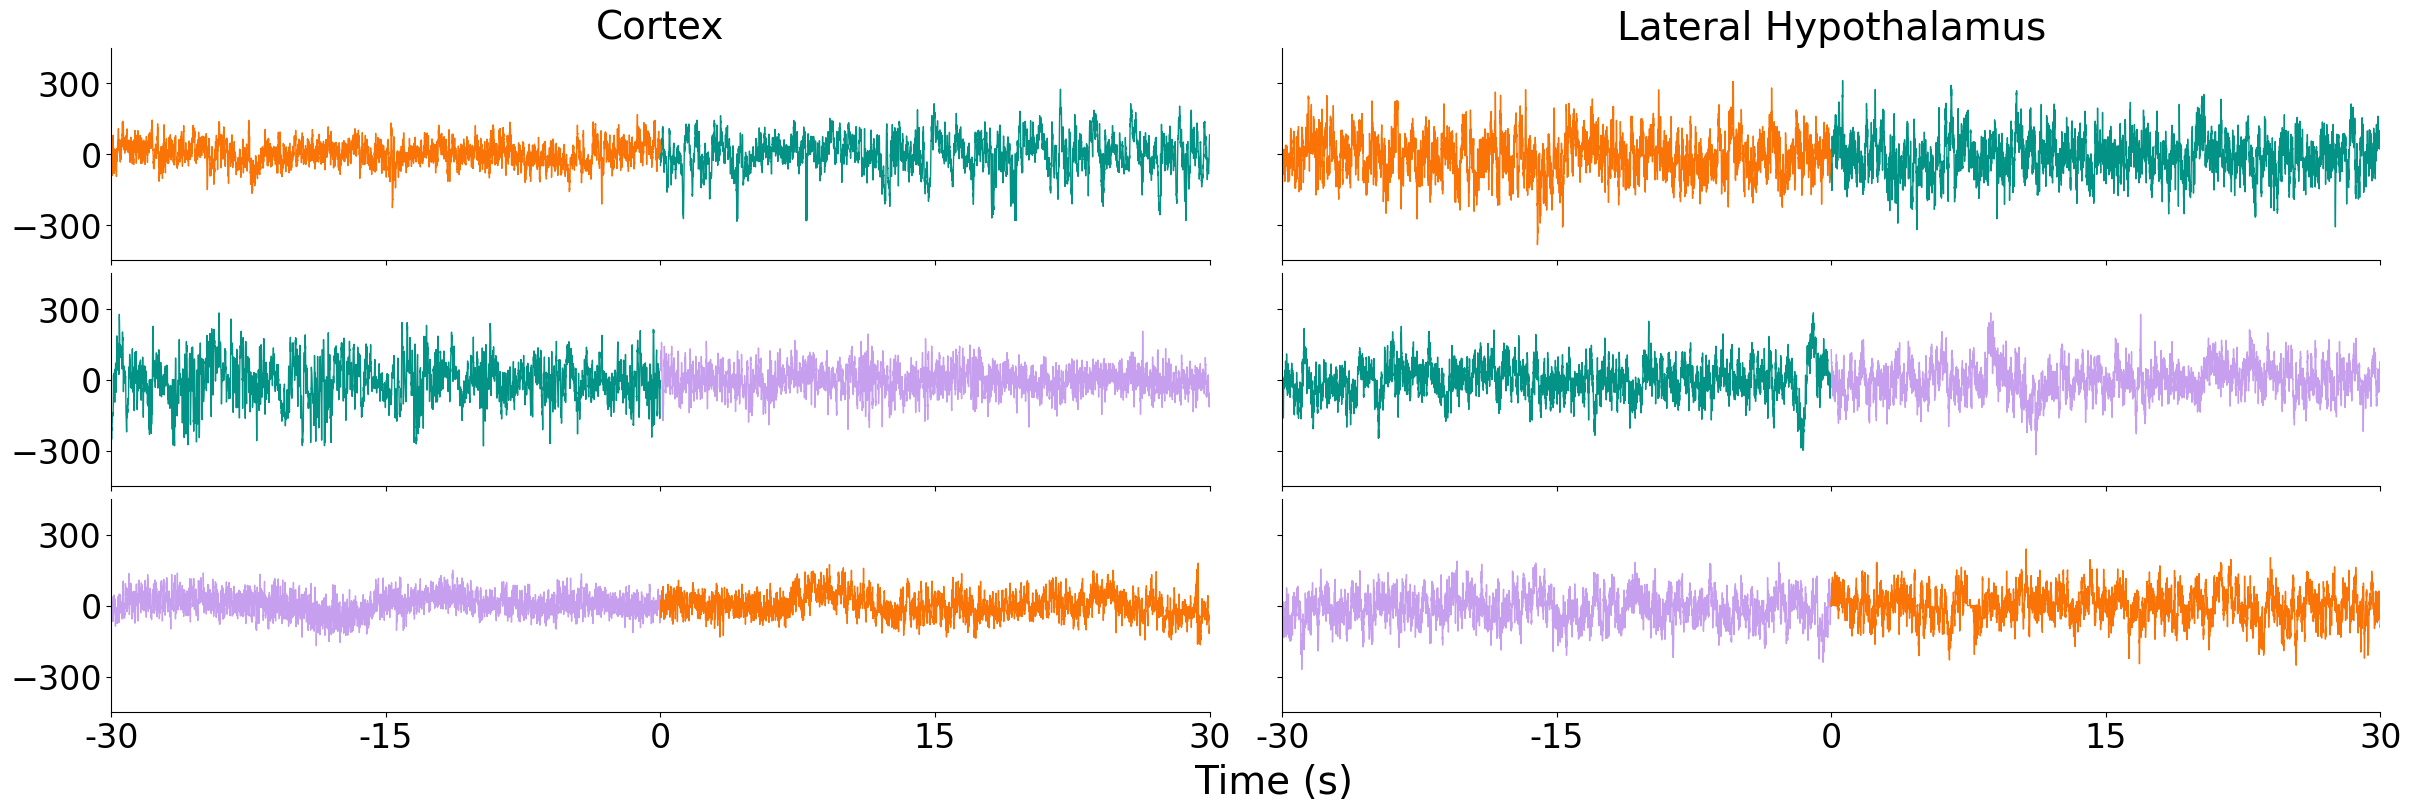

In [65]:
trans_dict = {"WAKE_NREM": [7, 18], "NREM_REM": [-17, 6], "REM_WAKE": [-1, -2]}
# trans_dict = {"WAKE_NREM": [17, 54], "NREM_REM": [41, 9], "REM_WAKE": [5, 11]}
color_dict = {"NREM": "#029386", "REM": "#c79fef", "WAKE": "#f97306"}
fig, axs = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(24, 8),
    sharey=True,
    sharex=True,
    constrained_layout=True,
)
window = 30
tmp_time_1 = np.arange(-window, 0, 1 / 250)
tmp_time_2 = np.arange(0, window, 1 / 250)
for ind, (transition, trans_inds) in enumerate(trans_dict.items()):
    tmp_ax = axs[ind, :]
    for ind2, region in enumerate(["ctx", "hyp"]):
        ch_ind = 0 if region == "ctx" else 1
        ax = tmp_ax[ind2]
        states = transition.split("_")
        ax.plot(
            tmp_time_1,
            trace_dict[states[0]][region]["raw"]["trace"][trans_inds[0]][
                -window * 250 :, ch_ind
            ],
            c=color_dict[states[0]],
            lw=1,
        )
        ax.plot(
            tmp_time_2,
            trace_dict[states[1]][region]["raw"]["trace"][trans_inds[1]][
                : window * 250, ch_ind
            ],
            c=color_dict[states[1]],
            lw=1,
        )
        ax.set_xlim(-window, window)
        ax.spines[["top", "right"]].set_visible(False)
    # tmp_ax[0].set_ylabel("\n".join(transition.split("_")), rotation=0, labelpad=30)
axs[-1, 0].set_xticks(
    ticks=np.arange(-window, window + 1, np.ceil((window * 2) / 4)),
    labels=np.arange(-window, window + 1, np.ceil((window * 2) / 4)).astype(int),
)
# ax2.legend()
# axs[0, 0].set_ylabel("NREM", rotation=0)
# axs[1, 0].set_ylabel("REM", rotation=0)
# axs[2, 0].set_ylabel("WAKE", rotation=0)
axs[0, 0].set_ylim([-450, 450])
axs[0, 0].set_yticks(ticks=np.arange(-300, 301, 300))
# axs[-1, -1].legend(markerscale=10, numpoints=100)
axs[0, 0].set_title("Cortex")
axs[0, 1].set_title("Lateral Hypothalamus")
# fig.supylabel("Amplitude ($\\mu$V)", x=-0.02, fontsize=BIGGER_SIZE)
fig.supxlabel("           Time (s)", fontsize=BIGGER_SIZE)
fig.savefig(
    Path(
        "/gpfs01/born/animal/DanielG/hypo_sleep/figures/plots/",
        "raw_trace_trans_brain_states_1.png",
    ),
    dpi=600,
    facecolor="white",
    transparent=False,
    bbox_inches="tight",
)
# fig.suptitle("Raw Trace across Brain States and Regions", y=1.04)

## Caclulate Statistics on Signal Envelope

In [53]:
trace_dict["NREM"]["ctx"]["raw"]["trace"][1].shape, trace_dict["NREM"]["hyp"]["raw"][
    "trace"
][1].shape

((52250, 1), (52250, 6))

(array([3.42145966e-04, 1.17751534e-03, 1.83514655e-03, 2.55054266e-03,
        3.19484350e-03, 3.91468307e-03, 4.51454937e-03, 5.18106749e-03,
        5.32770148e-03, 5.37657947e-03, 6.10974940e-03, 6.50521682e-03,
        6.77626752e-03, 6.66962462e-03, 6.67851153e-03, 7.02065749e-03,
        6.90512769e-03, 6.77626752e-03, 6.76293715e-03, 6.91401459e-03,
        6.67851153e-03, 6.18528812e-03, 6.55853826e-03, 6.23416611e-03,
        5.67429090e-03, 5.62541290e-03, 5.69650817e-03, 5.33658838e-03,
        5.18551094e-03, 5.12330259e-03, 5.12774604e-03, 4.26127249e-03,
        4.26127249e-03, 3.95911761e-03, 3.87024853e-03, 3.50588529e-03,
        3.60364128e-03, 3.17706969e-03, 3.07042679e-03, 3.11930478e-03,
        2.76827191e-03, 2.39502176e-03, 2.34170032e-03, 2.19506633e-03,
        2.05731925e-03, 1.97733708e-03, 1.63074766e-03, 1.60853039e-03,
        1.47522676e-03, 1.24861060e-03, 1.07087244e-03, 1.04865517e-03,
        8.97577730e-04, 9.50899179e-04, 7.95378285e-04, 6.398573

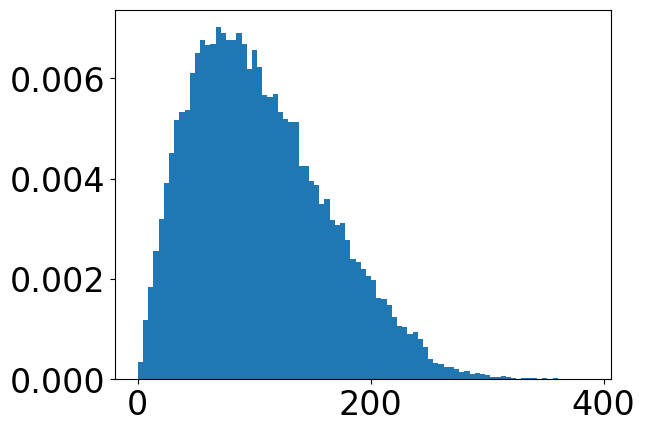

In [ ]:
h1 = plt.hist(
    signal_envelope(
        trace_dict["NREM"]["ctx"]["raw"]["trace"][1].flatten()[
            ~np.isnan(trace_dict["NREM"]["ctx"]["raw"]["trace"][1].flatten())
        ]
    ),
    bins="fd",
    density=True,
)

In [30]:
trace_dict["2025-02-18_09-19-26"]["REM"]["hyp"]["raw"]["trace"][0].shape

(29750, 32)

In [36]:
env_dict = {
    date: {
        region: {state: {} for state in ["NREM", "REM", "WAKE"]}
        for region in ["ctx", "hyp"]
    }
    for date in session_dict.keys()
}
for date, date_dict in env_dict.items():
    for region, reg_dict in date_dict.items():
        for state in reg_dict.keys():
            for trace in trace_dict[date][state][region]["raw"]["trace"]:
                for ind, ch in enumerate(trace.T):
                    if ind not in env_dict[date][region][state].keys():
                        env_dict[date][region][state][ind] = []
                    env_dict[date][region][state][ind].append(
                        np.mean(signal_envelope(ch[~np.isnan(ch)]))
                    )
for date, date_dict in env_dict.items():
    for region, reg_dict in date_dict.items():
        for state, traces in reg_dict.items():
            for ind, trace in traces.items():
                env_dict[date][region][state][ind] = np.array(trace)

In [51]:
sum_dict = {
    date: {
        region: {state: None for state in ["NREM", "REM", "WAKE"]}
        for region in ["ctx", "hyp"]
    }
    for date in session_dict.keys()
}
for date, date_dict in env_dict.items():
    for region, reg_dict in date_dict.items():
        for state, traces in reg_dict.items():
            sum_dict[date][region][state] = np.stack(
                [val for val in traces.values()], axis=0
            )

In [53]:
sum_dict["2025-02-18_09-19-26"]["ctx"]["NREM"].shape

(1, 61)

In [76]:
summed_state_dict = {
    region: {state: [] for state in ["NREM", "REM", "WAKE"]}
    for region in ["ctx", "hyp"]
}
for date, date_dict in sum_dict.items():
    for region, reg_dict in date_dict.items():
        for state, traces in reg_dict.items():
            summed_state_dict[region][state].append(traces)
for region, reg_dict in summed_state_dict.items():
    for state, traces in reg_dict.items():
        summed_state_dict[region][state] = np.concatenate(traces, axis=1).mean(axis=0)

In [81]:
state_list = ["WAKE", "NREM", "REM", "WAKE"]
mwu_dict = {
    region: {
        f"{state1}_{state2}": {}
        for state1, state2 in zip(state_list[:-1], state_list[1:])
    }
    for region in ["ctx", "hyp"]
}
for region in mwu_dict.keys():
    for state1, state2 in zip(state_list[:-1], state_list[1:]):
        mwu_dict[region][f"{state1}_{state2}"] = stats.mannwhitneyu(
            summed_state_dict[region][state1],
            summed_state_dict[region][state2],
            alternative="two-sided",
            # axis=0,
            # method="auto",
        )

In [83]:
corr_stats = {}
for region in mwu_dict.keys():
    corr_stats[region] = {}
    pvals = []
    state_list = []
    for state, res in mwu_dict[region].items():
        pvals.append(res.pvalue)
        state_list.append(state)
    reject, corr_pvals, _, _ = sm.stats.multipletests(
        pvals, method="bonferroni", alpha=0.05
    )
    corr_stats[region]["pvals"] = corr_pvals
    corr_stats[region]["reject"] = reject
    corr_stats[region]["comp"] = state_list

In [84]:
corr_stats

{'ctx': {'pvals': array([8.44866599e-31, 4.43587614e-26, 2.01708336e-10]),
  'reject': array([ True,  True,  True]),
  'comp': ['WAKE_NREM', 'NREM_REM', 'REM_WAKE']},
 'hyp': {'pvals': array([2.05025666e-07, 1.00000000e+00, 3.18534359e-05]),
  'reject': array([ True, False,  True]),
  'comp': ['WAKE_NREM', 'NREM_REM', 'REM_WAKE']}}

In [ ]:
from scipy.stats import norm

# Example: fit a Gaussian to the histogram of state_data
data = state_data  # use your variable containing the data

# Fit a normal distribution to the data
mu, std = norm.fit(data)

# Plot histogram
axs[0].hist(data, bins=nbins, density=True, alpha=0.6, color=color_dict["WAKE"])

# Plot the fitted Gaussian
xmin, xmax = axs[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
axs[0].plot(x, p, 'k', linewidth=2, label=f'Gaussian fit\n$\mu$={mu:.2f}, $\sigma$={std:.2f}')
axs[0].legend()

In [95]:
from scipy.stats import norm

<>:93: SyntaxWarning: invalid escape sequence '\m'
<>:93: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3878022/872465343.py:93: SyntaxWarning: invalid escape sequence '\m'
  axs[1].set_xlabel("Amplitude of Signal Envelope ($\mu V$)")


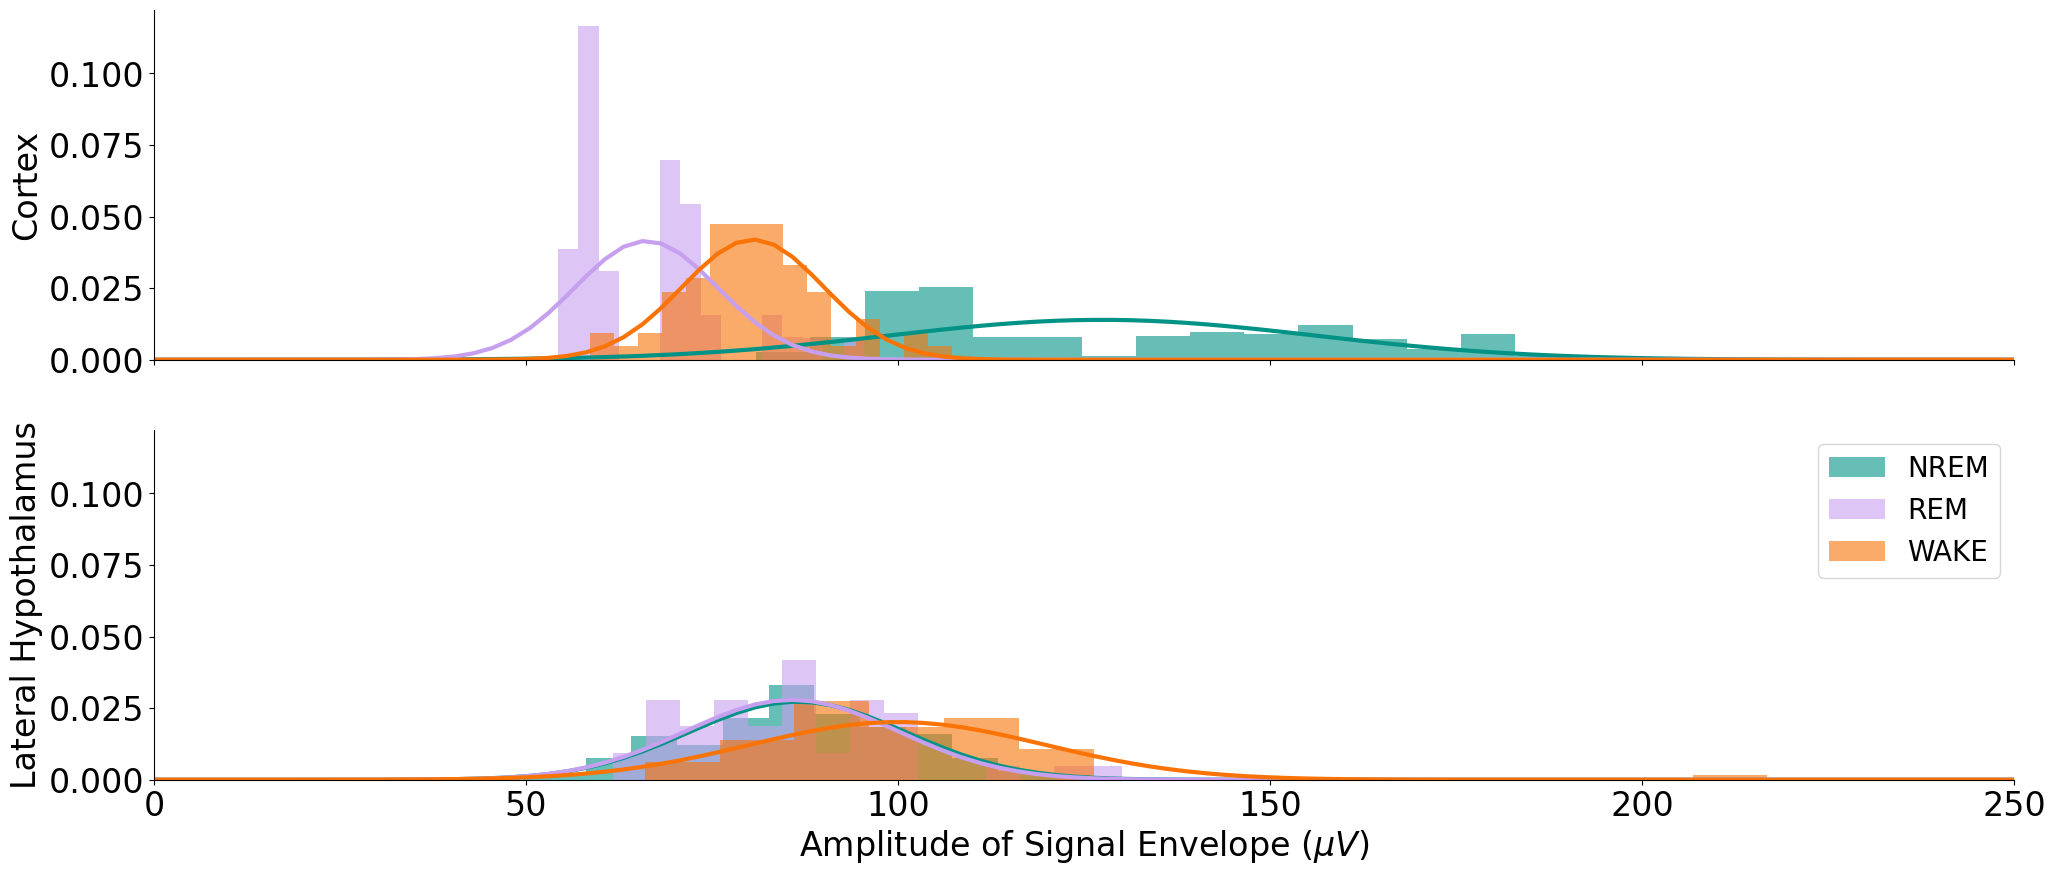

In [97]:
color_dict = {"NREM": "#029386", "REM": "#c79fef", "WAKE": "#f97306"}

nrows = 2
fig, axs = plt.subplots(
    nrows=nrows,
    figsize=(24, 10),
    sharex=True,
    sharey=True,
)
# fig.subplots_adjust(hspace=-0.5)
nbins = 15
for state, state_data in summed_state_dict["ctx"].items():
    # heights, edges = np.histogram(state_data, bins=nbins, density=True)
    # bin_centers = (edges[:-1] + edges[1:]) / 2
    heights, bins, _ = axs[0].hist(
        state_data, bins=nbins, density=True, alpha=0.6, color=color_dict[state]
    )
    # axs[0].bar(
    #     bin_centers,
    #     heights,
    #     alpha=0.6,
    #     width=np.diff(edges),
    #     color=color_dict[state],
    #     align="center",
    #     edgecolor=color_dict[state],
    # )
    # axs[0].fill_between(
    #     bin_centers,
    #     heights,
    #     step="mid",
    #     alpha=0.3,
    #     color=color_dict[state],
    # )
    # axs[0].plot(bin_centers, heights, lw=2, c=color_dict[state])
    # axs[0].xaxis.set_tick_params(labelbottom=False, bottom=False)
    mu, std = norm.fit(state_data)
    x = np.linspace(0, 250, 100)
    p = norm.pdf(x, mu, std)
    axs[0].plot(
        x,
        p,
        c=color_dict[state],
        linewidth=3,
    )  # label=f'Gaussian fit\n$\mu$={mu:.2f}, $\sigma$={std:.2f}')
    axs[0].yaxis.set_tick_params(labelleft=True, left=True)
    # axs[0].set_yticks([])
    axs[0].set_ylabel("Cortex")
    # axs[0].patch.set_alpha(0)
    axs[0].spines[["right", "top"]].set_visible(False)

for state, state_data in summed_state_dict["hyp"].items():
    heights, edges = np.histogram(state_data, bins=nbins, density=True)
    bin_centers = (edges[:-1] + edges[1:]) / 2
    # Plot filled histogram line
    axs[1].hist(
        state_data,
        bins=nbins,
        density=True,
        alpha=0.6,
        color=color_dict[state],
        label=state,
    )
    mu, std = norm.fit(state_data)
    x = np.linspace(0, 250, 100)
    p = norm.pdf(x, mu, std)
    axs[1].plot(
        x,
        p,
        c=color_dict[state],
        linewidth=3,
    )
    # axs[1].bar(
    #     bin_centers,
    #     heights,
    #     alpha=0.6,
    #     width=np.diff(edges),
    #     color=color_dict[state],
    #     align="center",
    #     edgecolor=color_dict[state],
    # )
    # axs[1].fill_between(
    #     bin_centers, heights, step="mid", alpha=0.6, color=color_dict[state]
    # )
    # axs[1].plot(bin_centers, heights, lw=2, c=color_dict[state])
# axs[1].set_yticks([])
axs[1].set_ylabel("Lateral Hypothalamus")
axs[1].yaxis.set_tick_params(labelleft=True, left=True)
# axs[1].patch.set_alpha(0)
axs[1].spines[["right", "top"]].set_visible(False)
axs[1].set_xlim([0, 250])
# ax.set_ylabel(f"{sub_ordered_chs[i]}             ")
# axs[-1].vlines(x = 325, ymin=0, ymax=0.01, lw=2, c="r")
axs[1].set_xlabel("Amplitude of Signal Envelope ($\mu V$)")
axs[1].legend()

In [ ]:
env_dict = {
    region: {state: {} for state in ["NREM", "REM", "WAKE"]}
    for region in ["ctx", "hyp"]
}
for region, reg_dict in env_dict.items():
    for state in reg_dict.keys():
        for trace in trace_dict[state][region]["raw"]["trace"]:
            for ind, ch in enumerate(trace.T):
                if ind not in env_dict[region][state].keys():
                    env_dict[region][state][ind] = []
                env_dict[region][state][ind].append(
                    np.mean(signal_envelope(ch[~np.isnan(ch)]))
                )
for region, reg_dict in env_dict.items():
    for state, traces in reg_dict.items():
        for ind, trace in traces.items():
            env_dict[region][state][ind] = np.concatenate(trace, axis=0)
hist_dict = {
    region: {
        state: {"heights": None, "edges": None, "width": None}
        for state in ["WAKE", "NREM", "REM"]
    }
    for region in ["ctx", "hyp"]
}
for region, reg_dict in env_dict.items():
    if region == "hyp":
        for state, reg_data in reg_dict.items():
            nbins = 0
            new_edges = [np.inf, 0]
            tmp_heights = []
            for tmp_data in reg_data.values():
                # valid_inds = ~np.isnan(tmp_data.flatten())
                heights, edges = np.histogram(tmp_data, bins="fd")
                nbins = max(nbins, edges.size)
                new_edges = [min(new_edges[0], edges[0]), max(new_edges[1], edges[-1])]
            for tmp_data in reg_data.values():
                heights, edges = np.histogram(
                    tmp_data,
                    bins=np.linspace(0, new_edges[1], nbins),
                    density=True,
                )
                bin_centers = (edges[:-1] + edges[1:]) / 2
                tmp_heights.append(heights)
                # tmp_heights.append(heights / heights.sum())
            hist_dict[region][state]["heights"] = np.stack(tmp_heights)
            hist_dict[region][state]["edges"] = bin_centers
            hist_dict[region][state]["width"] = edges[1] - edges[0]
    elif region == "ctx":
        for state, reg_data in reg_dict.items():
            for key, trace in reg_data.items():
                # valid_inds = ~np.isnan(reg_data.flatten())
                heights, edges = np.histogram(trace.flatten(), bins="fd", density=True)
                bin_centers = (edges[:-1] + edges[1:]) / 2
                hist_dict[region][state]["heights"] = heights
                hist_dict[region][state]["edges"] = bin_centers
                hist_dict[region][state]["width"] = edges[1] - edges[0]

In [63]:
hist_dict = {
    region: {
        state: {"heights": None, "edges": None, "width": None}
        for state in ["WAKE", "NREM", "REM"]
    }
    for region in ["ctx", "hyp"]
}
for region, reg_dict in env_dict.items():
    if region == "hyp":
        for state, reg_data in reg_dict.items():
            nbins = 0
            new_edges = [np.inf, 0]
            tmp_heights = []
            for tmp_data in reg_data.values():
                # valid_inds = ~np.isnan(tmp_data.flatten())
                heights, edges = np.histogram(tmp_data, bins="fd")
                nbins = max(nbins, edges.size)
                new_edges = [min(new_edges[0], edges[0]), max(new_edges[1], edges[-1])]
            for tmp_data in reg_data.values():
                heights, edges = np.histogram(
                    tmp_data,
                    bins=np.linspace(0, new_edges[1], nbins),
                    density=True,
                )
                bin_centers = (edges[:-1] + edges[1:]) / 2
                tmp_heights.append(heights)
                # tmp_heights.append(heights / heights.sum())
            hist_dict[region][state]["heights"] = np.stack(tmp_heights)
            hist_dict[region][state]["edges"] = bin_centers
            hist_dict[region][state]["width"] = edges[1] - edges[0]
    elif region == "ctx":
        for state, reg_data in reg_dict.items():
            for key, trace in reg_data.items():
                # valid_inds = ~np.isnan(reg_data.flatten())
                heights, edges = np.histogram(trace.flatten(), bins="fd", density=True)
                bin_centers = (edges[:-1] + edges[1:]) / 2
                hist_dict[region][state]["heights"] = heights
                hist_dict[region][state]["edges"] = bin_centers
                hist_dict[region][state]["width"] = edges[1] - edges[0]

In [26]:
state_list = ["WAKE", "NREM", "REM", "WAKE"]
ttest_dict = {region: {} for region in ["ctx", "hyp"]}
mwu_dict = {
    region: {
        f"{state1}_{state2}": {}
        for state1, state2 in zip(state_list[:-1], state_list[1:])
    }
    for region in ["ctx", "hyp"]
}
kde_dict = {
    region: {state: None for state in ["WAKE", "NREM", "REM"]}
    for region in ["ctx", "hyp"]
}

In [27]:
# rng = np.random.default_rng(66)
permutation = stats.PermutationMethod(100)
for region in mwu_dict.keys():
    for state1, state2 in zip(state_list[:-1], state_list[1:]):
        chs = sub_ordered_chs if region == "hyp" else ["39"]
        for i in range(len(chs)):
            mwu_dict[region][f"{state1}_{state2}"][i] = stats.mannwhitneyu(
                env_dict[region][state1][i],
                env_dict[region][state2][i],
                alternative="two-sided",
                # axis=0,
                # method="auto",
            )

In [33]:
cases = np.array(
    [
        (reg, trans, ch)
        for reg, reg_dict in mwu_dict.items()
        for trans, tmp in reg_dict.items()
        for ch in tmp.keys()
    ]
)

In [51]:
stat_dict = {}
for region, reg_dict in mwu_dict.items():

    cases = np.array(
        [(region, trans, ch) for trans, tmp in reg_dict.items() for ch in tmp.keys()]
    )
    pvals = np.array(
        [
            tmp.pvalue
            # for reg_dict in mwu_dict.values()
            for state in reg_dict.values()
            for tmp in state.values()
        ]
    )
    reject, corr_p, _, _ = sm.stats.multipletests(
        pvals, alpha=0.05, method="bonferroni"
    )
    stat_dict[region] = {"cases": cases, "reject": reject, "corrected_pvals": corr_p}

In [59]:
env_dict["ctx"].keys()

dict_keys(['NREM', 'REM', 'WAKE'])

<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3744762/2694133665.py:47: SyntaxWarning: invalid escape sequence '\m'
  axs[-1].set_xlabel("Amplitude ($\mu V$)")


Text(0.5, 0, 'Amplitude ($\\mu V$)')

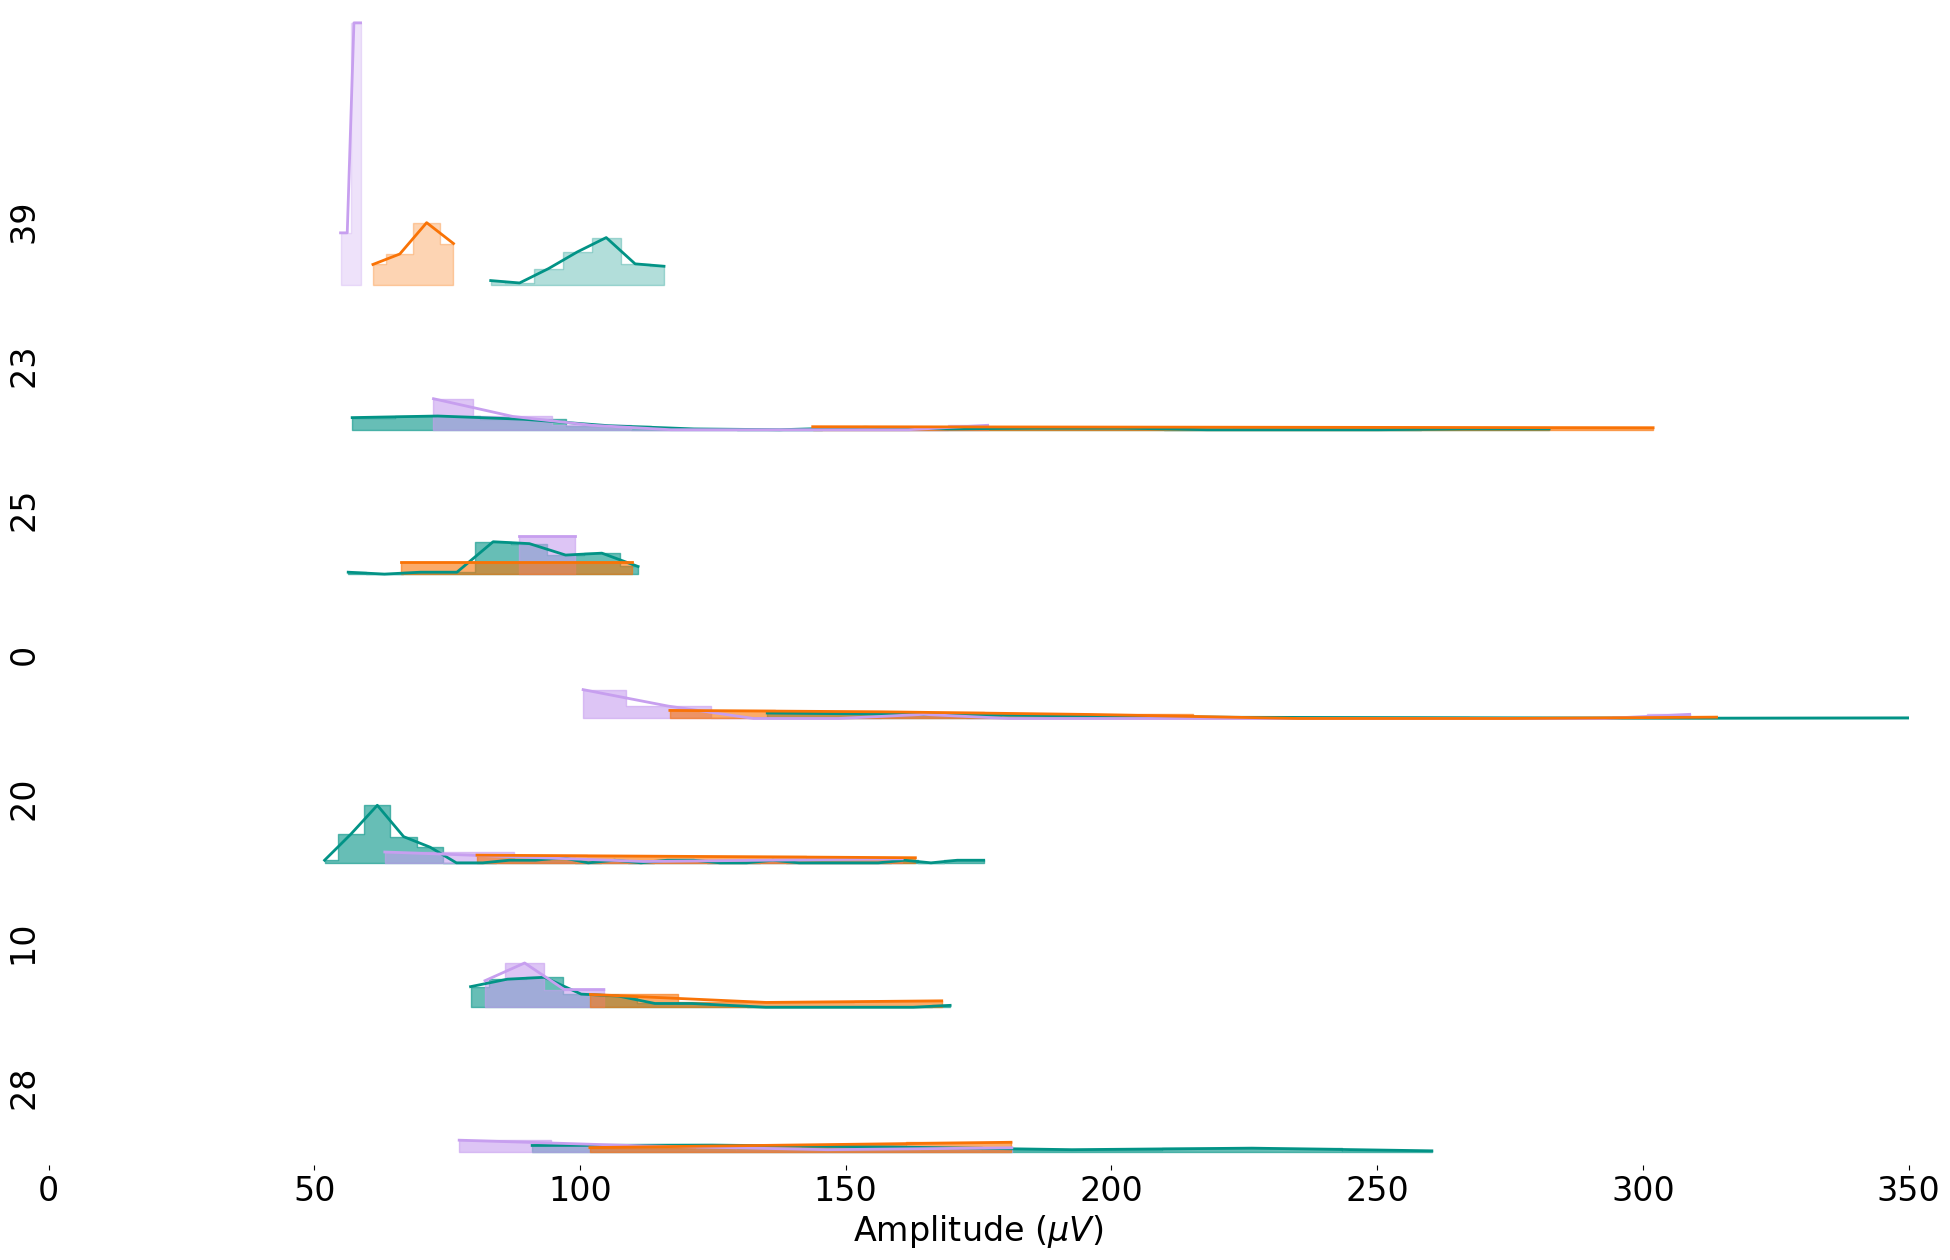

In [61]:
color_dict = {"NREM": "#029386", "REM": "#c79fef", "WAKE": "#f97306"}

nrows = 6 + 1
fig, axs = plt.subplots(
    nrows=nrows,
    figsize=(24, 15),
    sharex=True,
    sharey=True,
)
fig.subplots_adjust(hspace=-0.5)

for state, state_data in env_dict["ctx"].items():
    heights, edges = np.histogram(state_data[0], bins="fd", density=True)
    bin_centers = (edges[:-1] + edges[1:]) / 2
    axs[0].fill_between(
        bin_centers,
        heights,
        step="mid",
        alpha=0.3,
        color=color_dict[state],
    )
    axs[0].plot(bin_centers, heights, lw=2, c=color_dict[state])
    axs[0].xaxis.set_tick_params(labelbottom=False, bottom=False)
    axs[0].set_yticks([])
    axs[0].set_ylabel(f"39             ")
    axs[0].patch.set_alpha(0)
    axs[0].spines[["left", "right", "bottom", "top"]].set_visible(False)

for i, ax in enumerate(axs[1:]):
    for j, (state, state_data) in enumerate(env_dict["hyp"].items()):
        heights, edges = np.histogram(state_data[i], bins="fd", density=True)
        bin_centers = (edges[:-1] + edges[1:]) / 2
        # Plot filled histogram line
        ax.fill_between(
            bin_centers, heights, step="mid", alpha=0.6, color=color_dict[state]
        )
        ax.plot(bin_centers, heights, lw=2, c=color_dict[state])
    ax.set_yticks([])
    # ax.yaxis.set_tick_params(labelleft=True, left=True)
    ax.patch.set_alpha(0)
    ax.spines[["left", "right", "bottom", "top"]].set_visible(False)
    if i != nrows - 2:
        ax.xaxis.set_tick_params(labelbottom=False, bottom=False)
    ax.set_xlim([0, 350])
    ax.set_ylabel(f"{sub_ordered_chs[i]}             ")
# axs[-1].vlines(x = 325, ymin=0, ymax=0.01, lw=2, c="r")
axs[-1].set_xlabel("Amplitude ($\mu V$)")

<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3744762/1759624824.py:44: SyntaxWarning: invalid escape sequence '\m'
  axs[-1].set_xlabel("Amplitude ($\mu V$)")


Text(0.5, 0, 'Amplitude ($\\mu V$)')

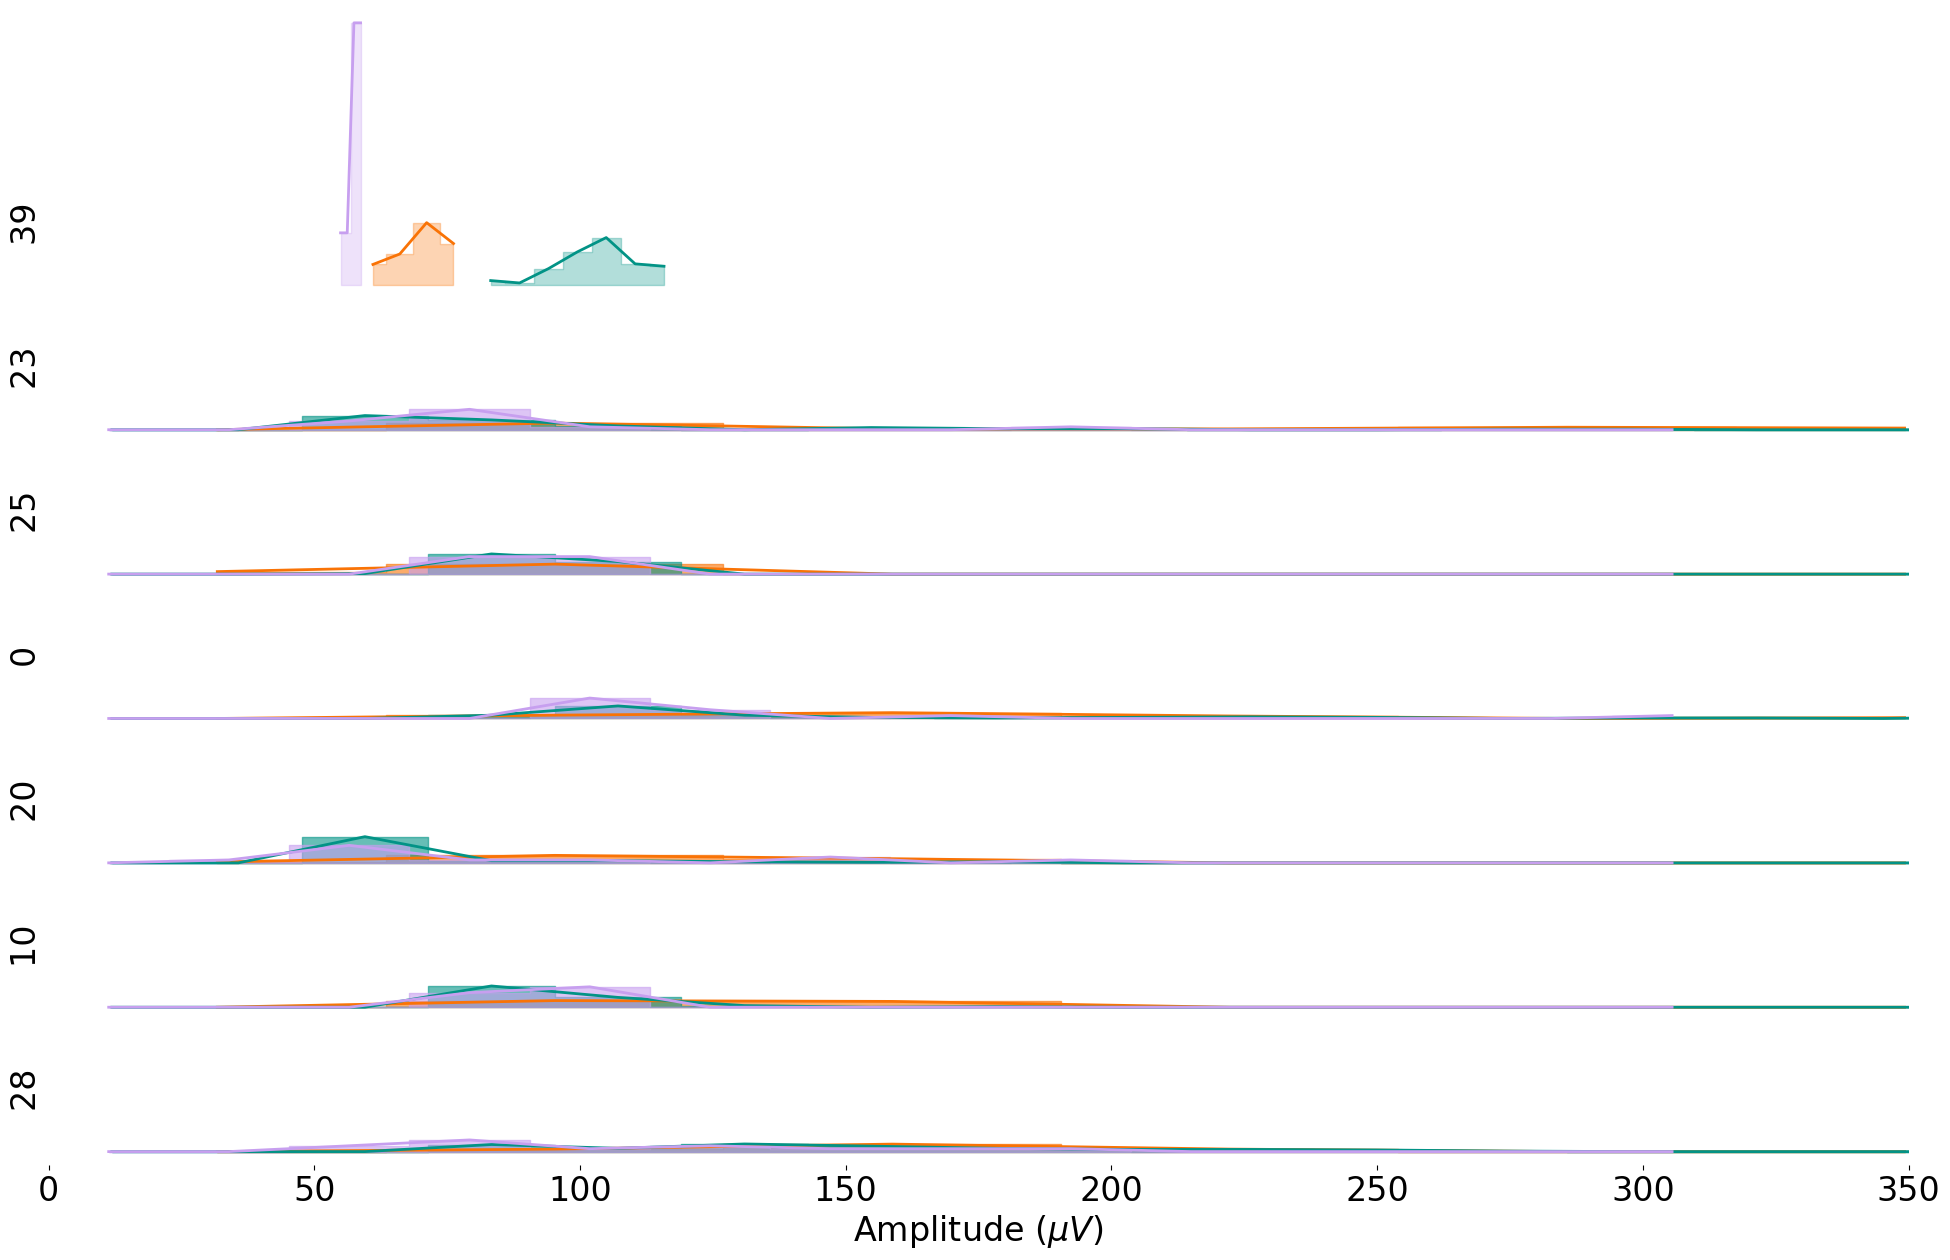

In [64]:
color_dict = {"NREM": "#029386", "REM": "#c79fef", "WAKE": "#f97306"}

nrows = 6 + 1
fig, axs = plt.subplots(
    nrows=nrows,
    figsize=(24, 15),
    sharex=True,
    sharey=True,
)
fig.subplots_adjust(hspace=-0.5)

for state, state_data in hist_dict["ctx"].items():
    axs[0].fill_between(
        state_data["edges"],
        state_data["heights"],
        step="mid",
        alpha=0.3,
        color=color_dict[state],
    )
    axs[0].plot(state_data["edges"], state_data["heights"], lw=2, c=color_dict[state])
    axs[0].xaxis.set_tick_params(labelbottom=False, bottom=False)
    axs[0].set_yticks([])
    axs[0].set_ylabel(f"39             ")
    axs[0].patch.set_alpha(0)
    axs[0].spines[["left", "right", "bottom", "top"]].set_visible(False)

for i, ax in enumerate(axs[1:]):
    for j, (state, state_data) in enumerate(hist_dict["hyp"].items()):
        heights = state_data["heights"][i]
        edges = state_data["edges"]

        # Plot filled histogram line
        ax.fill_between(edges, heights, step="mid", alpha=0.6, color=color_dict[state])
        ax.plot(edges, heights, lw=2, c=color_dict[state])
    ax.set_yticks([])
    # ax.yaxis.set_tick_params(labelleft=True, left=True)
    ax.patch.set_alpha(0)
    ax.spines[["left", "right", "bottom", "top"]].set_visible(False)
    if i != nrows - 2:
        ax.xaxis.set_tick_params(labelbottom=False, bottom=False)
    ax.set_xlim([0, 350])
    ax.set_ylabel(f"{sub_ordered_chs[i]}             ")
# axs[-1].vlines(x = 325, ymin=0, ymax=0.01, lw=2, c="r")
axs[-1].set_xlabel("Amplitude ($\mu V$)")

In [78]:
env_dict["ctx"]["NREM"].shape

(2499750, 1)

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3478399/894414961.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("Amplitude ($\mu V$)")


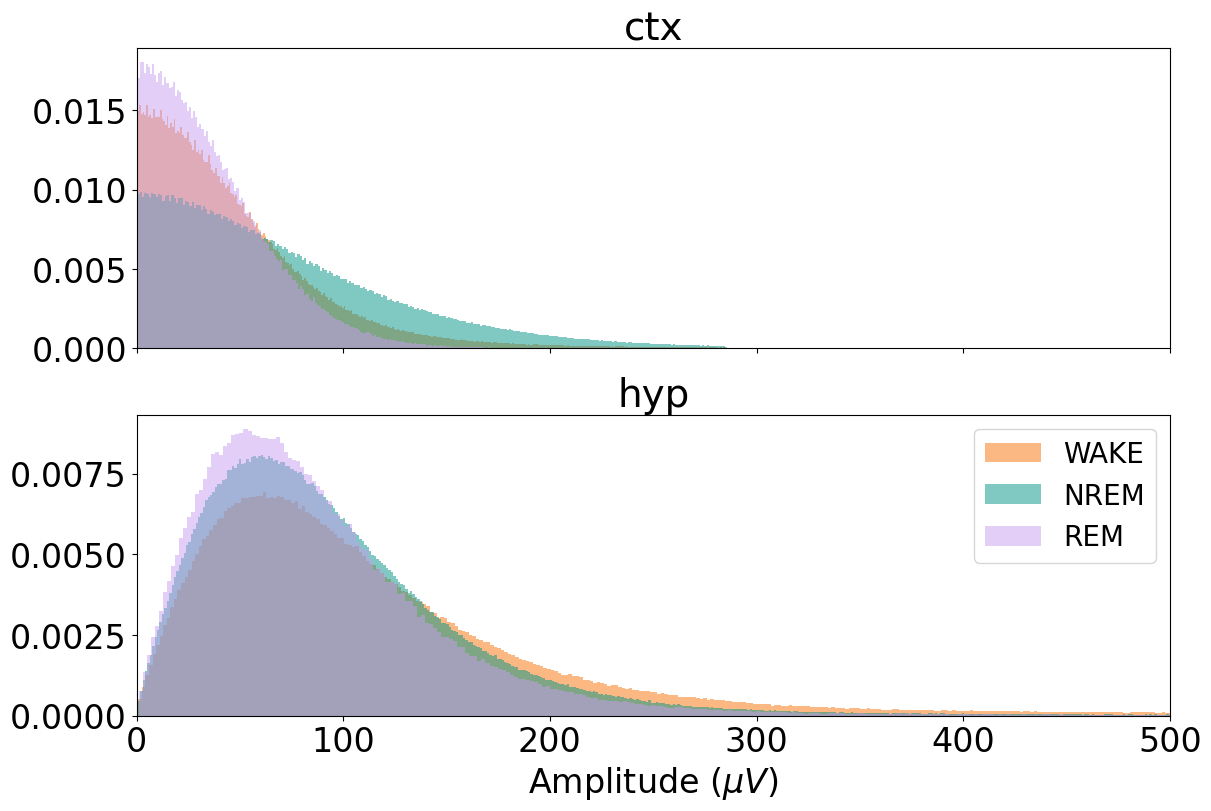

In [79]:
color_dict = {"NREM": "#029386", "REM": "#c79fef", "WAKE": "#f97306"}
fig, axs = plt.subplots(nrows=2, figsize=(12, 8), sharex=True, constrained_layout=True)
for ax, (region, reg_dict) in zip(axs.ravel(), hist_dict.items()):
    for state, data in reg_dict.items():
        ax.hist(
            env_dict[region][state][:, 0],
            data["edges"],
            # width=data["width"],
            density=True,
            alpha=0.5,
            color=color_dict[state],
            label=state,
        )

    ax.set_title(region)
ax.set_xlabel("Amplitude ($\mu V$)")
ax.set_xlim([0, 500])
ax.legend()

In [53]:
hist_dict

NameError: name 'hist_dict' is not defined

In [ ]:
color_dict = {"NREM": "#029386", "REM": "#c79fef", "WAKE": "#f97306"}
fig, ax = plt.subplots(
    figsize=(12, 8),
    constrained_layout=True,
)

for

ax1.spines[["right", "top"]].set_visible(False)

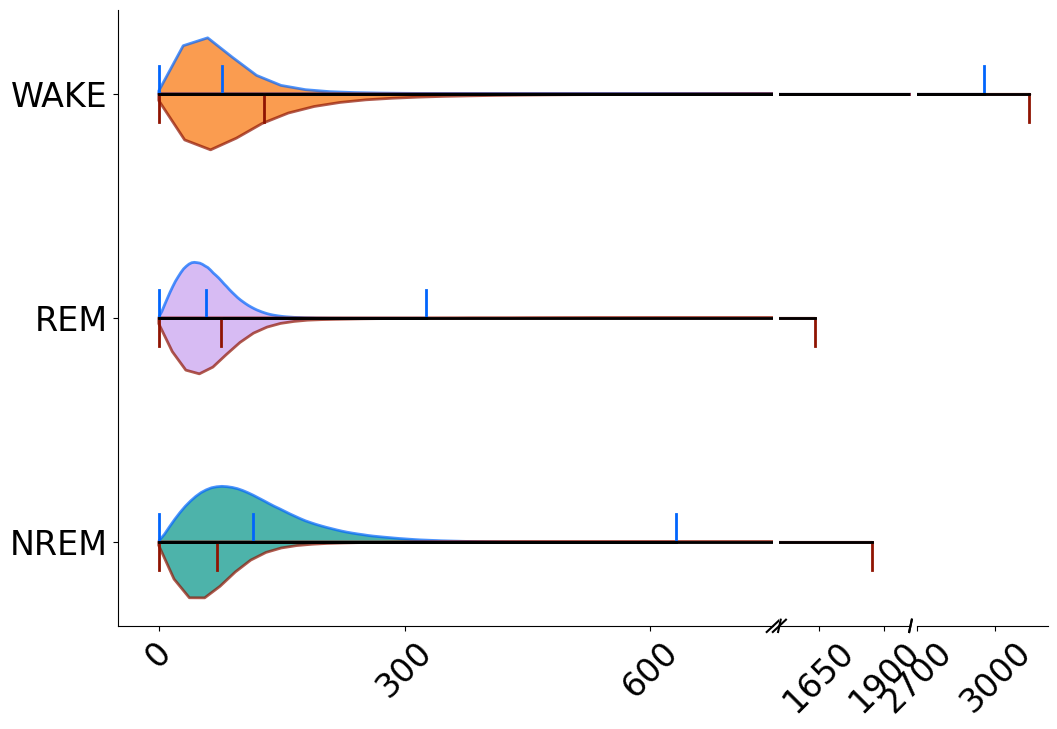

In [125]:
color_dict = {"NREM": "#029386", "REM": "#c79fef", "WAKE": "#f97306"}
fig, (ax1, ax2, ax3) = plt.subplots(
    1,
    3,
    sharey=True,
    figsize=(12, 8),
    gridspec_kw={"width_ratios": [5, 1, 1]},
    # constrained_layout=True,
)
fig.subplots_adjust(wspace=0.02)

data = [val for val in env_dict["ctx"].values()]
labels = [val for val in env_dict["ctx"].keys()]
for region, reg_dict in env_dict.items():
    side = "high" if region == "ctx" else "low"
    mean_color = "#0165fc" if region == "ctx" else "#8f1402"
    for ind, (label, data) in enumerate(reg_dict.items()):
        vplot1 = ax1.violinplot(
            data,
            orientation="horizontal",
            showmeans=True,
            positions=[ind + 1],
            side=side,
        )
        vplot2 = ax2.violinplot(
            data,
            orientation="horizontal",
            showmeans=True,
            positions=[ind + 1],
            side=side,
        )
        vplot3 = ax3.violinplot(
            data,
            orientation="horizontal",
            showmeans=True,
            positions=[ind + 1],
            side=side,
        )
        for tmp_plot in [vplot1, vplot2, vplot3]:
            tmp_plot["cmeans"].set_color(mean_color)
            tmp_plot["cmeans"].set_linewidth(2)
            tmp_plot["cmins"].set_color(mean_color)
            tmp_plot["cmins"].set_linewidth(2)
            tmp_plot["cmaxes"].set_color(mean_color)
            tmp_plot["cmaxes"].set_linewidth(2)
            tmp_plot["cbars"].set_color("black")
            tmp_plot["cbars"].set_linewidth(2)
            for pc in tmp_plot["bodies"]:
                pc.set_facecolor(color_dict[label])
                pc.set_linewidth(2)
                pc.set_alpha(0.7)
                pc.set_edgecolor(mean_color)
ax1.set_xlim(-50, 750)  # left range
ax2.set_xlim(1500, 2000)
ax3.set_xlim(2700, 3200)
ax1.set_xticks([0, 300, 600])
ax2.set_xticks([1650, 1900])
ax3.set_xticks([2700, 3000])
ax1.xaxis.set_tick_params(rotation=45)
ax2.xaxis.set_tick_params(rotation=45)
ax3.xaxis.set_tick_params(rotation=45)
ax1.set_yticks([1, 2, 3], labels)
ax1.spines[["right", "top"]].set_visible(False)
ax2.spines[["left", "right", "top"]].set_visible(False)
ax3.spines[["left", "right", "top"]].set_visible(False)
ax2.yaxis.set_visible(False)
ax3.yaxis.set_visible(False)
ax1.tick_params(labelright=False)
ax2.tick_params(labelright=False)
d = 0.01
kwargs = dict(transform=ax1.transAxes, color="k", clip_on=False)
ax1.plot((1 - d, 1 + d), (-d, d), **kwargs)
kwargs.update(transform=ax2.transAxes)
ax2.plot((-d * 5, d * 5), (-d, d), **kwargs)
ax2.plot((1 - d, 1 + d), (-d, d), **kwargs)
ax3.plot((-d * 1, d * 1), (-d, d), **kwargs)

In [ ]:
vplot1["cmeans"].set_edgecolor()